# 🧠 Psychiatric Medication Sentiment Analysis
### End-to-end ML pipeline · PubMedBERT · Binary Classification

**Dataset:** [UCI Drug Review (Drugs.com)](https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018)  
**Model:** PubMedBERT + Auxiliary Feature MLP Head  
**Target:** Binary sentiment (positive / negative) from patient reviews

---
| Stage | Description |
|---|---|
| 1️⃣ Setup | Install deps, mount Drive, configure GPU |
| 2️⃣ Data | Download dataset, filter psych conditions |
| 3️⃣ Preprocess | Clean text, engineer 8 auxiliary features, binarise labels |
| 4️⃣ Dataset | PyTorch Dataset + DataLoaders |
| 5️⃣ Model | PubMedBERT + AuxMLP hybrid classifier |
| 6️⃣ Train | Fine-tune with MLflow tracking + early stopping |
| 7️⃣ Evaluate | Metrics, confusion matrix, ROC curve, SHAP |
| 8️⃣ Inference | Predict on new reviews |


## 1️⃣ Setup — GPU + Dependencies

In [ ]:
# ── Check GPU ──────────────────────────────────────────────────────────────
import torch
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None (CPU only)"
print(f"GPU: {gpu}")
print(f"CUDA available: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    print("\n⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU")


In [ ]:
# ── Install dependencies ───────────────────────────────────────────────────
%pip install -q transformers==4.40.0 datasets accelerate evaluate \
             mlflow scikit-learn shap lightgbm kaggle pyarrow \
             matplotlib seaborn tqdm
print("✅ Dependencies installed")


## 2️⃣ Data — Download Dataset

**Two options:**
- **Option A (Real data):** Upload your `kaggle.json` API key
- **Option B (Mock data):** Skip to the next cell — synthetic data will be generated automatically


In [12]:
import os
from pathlib import Path

USE_MOCK_DATA = False  # ← True = synthetic data (instant), False = real Drugs.com dataset

Path("/content/data").mkdir(exist_ok=True)

if not USE_MOCK_DATA:
    import urllib.request

    files = {
        "drugsComTrain_raw.tsv": "https://raw.githubusercontent.com/semnan-university-ai/Drug-Review-Dataset/main/drugsComTrain_raw.tsv",
        "drugsComTest_raw.tsv":  "https://raw.githubusercontent.com/semnan-university-ai/Drug-Review-Dataset/main/drugsComTest_raw.tsv",
    }

    for filename, url in files.items():
        dest = f"/content/data/{filename}"
        if os.path.exists(dest):
            print(f"✅ Already downloaded: {filename}")
        else:
            print(f"Downloading {filename}  (~80MB, takes ~30s)...")
            urllib.request.urlretrieve(url, dest)
            size_mb = os.path.getsize(dest) / 1e6
            print(f"✅ {filename}  ({size_mb:.1f} MB)")

    print("\n✅ Dataset ready — no Kaggle account needed")
else:
    print("ℹ️  Mock data mode — set USE_MOCK_DATA=False for real results")


✅ drugsComTrain_raw.tsv  (84.3 MB)
✅ drugsComTest_raw.tsv  (28.1 MB)

✅ Dataset ready — no Kaggle account needed


## 3️⃣ Configuration

In [13]:
from dataclasses import dataclass, field
from pathlib import Path

@dataclass
class Config:
    # Paths
    raw_train:   str = "/content/data/drugsComTrain_raw.tsv"
    raw_test:    str = "/content/data/drugsComTest_raw.tsv"
    train_path:  str = "/content/data/train.parquet"
    val_path:    str = "/content/data/val.parquet"
    test_path:   str = "/content/data/test.parquet"
    ckpt_path:   str = "/content/models/best_model.pt"

    # Psychiatric conditions to keep
    psych_conditions: list = field(default_factory=lambda: [
        "depression", "anxiety", "bipolar disorder", "schizophrenia",
        "adhd", "ocd", "ptsd", "panic disorder", "insomnia",
        "major depressive disorder", "generalized anxiety disorder",
        "social anxiety disorder", "borderline personality disorder",
    ])

    # Label binarisation  (drop ambiguous middle band 5-7)
    positive_threshold: int = 7
    negative_threshold: int = 5

    # Splits
    val_split:   float = 0.10
    test_split:  float = 0.10
    random_seed: int   = 42

    # Model
    base_model:      str = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
    max_length:      int = 256      # reduced from 512 for Colab memory
    use_aux:         bool = True
    aux_feature_dim: int  = 16
    hidden_dim:      int  = 128
    dropout:         float = 0.1
    freeze_layers:   int  = 6

    # Training
    batch_size:      int   = 16
    eval_batch_size: int   = 32
    lr:              float = 2e-5
    weight_decay:    float = 0.01
    num_epochs:      int   = 4
    warmup_ratio:    float = 0.1
    grad_accum:      int   = 2
    fp16:            bool  = True
    eval_steps:      int   = 100
    patience:        int   = 3

CFG = Config()
Path("/content/data").mkdir(exist_ok=True)
Path("/content/models").mkdir(exist_ok=True)
Path("/content/outputs").mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Config ready · device={DEVICE}")


Config ready · device=cuda


## 4️⃣ Preprocessing — Feature Engineering + Label Binarisation

In [14]:
import html, re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ── Lexicons ───────────────────────────────────────────────────────────────
SIDE_EFFECT_TERMS = {
    "nausea","vomiting","dizziness","headache","fatigue","insomnia",
    "drowsiness","weight gain","weight loss","dry mouth","constipation",
    "diarrhea","anxiety","tremor","sweating","blurred vision",
    "sexual dysfunction","suicidal","withdrawal","rash","appetite",
    "memory","concentration","brain fog","palpitations","agitation",
    "akathisia","tardive","dyskinesia","hypomania","mania","sedation",
}
ADHERENCE_POS = {"still taking","still on","continue","stayed on","kept taking"}
ADHERENCE_NEG = {"stopped","discontinued","switched","quit","gave up","weaned off"}
NEGATION      = {"not","no","never","didn't","don't","doesn't","wasn't",
                 "isn't","won't","wouldn't","couldn't","can't","nothing"}
OUTCOME_POS   = {"stable","functioning","better","improved","recovery",
                 "remission","productive","normal","well","relief"}
OUTCOME_NEG   = {"relapsed","hospitalized","worse","deteriorated",
                 "breakdown","crisis","suicidal","overdose"}

def clean_text(t):
    if not isinstance(t, str): return ""
    t = html.unescape(t)
    t = re.sub(r"[^\x00-\x7F]+", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def side_effect_density(t):
    w = t.lower().split()
    return round(sum(1 for x in w if x in SIDE_EFFECT_TERMS) / max(len(w),1) * 100, 4)

def negation_score(t):
    w = t.lower().split()
    return round(sum(1 for x in w if x in NEGATION) / max(len(w),1), 4)

def adherence_flag(t):
    l = t.lower()
    if any(p in l for p in ADHERENCE_POS): return  1
    if any(p in l for p in ADHERENCE_NEG): return -1
    return 0

def outcome_score(t):
    w = t.lower().split()
    pos = sum(1 for x in w if x in OUTCOME_POS)
    neg = sum(1 for x in w if x in OUTCOME_NEG)
    return round((pos - neg) / max(len(w),1), 4)

def binarize(r):
    if r >= CFG.positive_threshold: return 1
    if r <= CFG.negative_threshold: return 0
    return None

# ── Mock data generator ────────────────────────────────────────────────────
def generate_mock(n=800):
    rng = np.random.default_rng(42)
    drugs = ["Sertraline","Fluoxetine","Lithium","Quetiapine","Lorazepam",
             "Bupropion","Venlafaxine","Lamotrigine","Aripiprazole","Clonazepam"]
    pos = ["This medication has been life changing. I finally feel like myself again. Still taking it.",
           "After years of struggling I found this works great. Significant improvement in mood.",
           "Finally sleeping and functioning normally. Very happy with results. Would recommend.",
           "Stable and productive for the first time in years. This drug saved my life."]
    neg = ["Awful side effects, nausea and dizziness every day. Stopped after a month.",
           "Made my anxiety so much worse. Switched to something else. Not recommended.",
           "Weight gain and brain fog were unbearable. Discontinued after two months.",
           "Didn't work for me at all. Relapsed badly. Would never recommend this."]
    rows = []
    for i in range(n):
        rating = int(rng.integers(1, 11))
        rows.append({
            "drugName":    rng.choice(drugs),
            "condition":   rng.choice(CFG.psych_conditions),
            "review":      rng.choice(pos if rating >= 7 else neg),
            "rating":      float(rating),
            "usefulCount": int(rng.integers(0, 100)),
        })
    return pd.DataFrame(rows)

# ── Load & preprocess ──────────────────────────────────────────────────────
def load_and_preprocess(use_mock=True):
    if use_mock:
        print("Generating mock data…")
        df = generate_mock(800)
    else:
        df_tr = pd.read_csv(CFG.raw_train, sep="\t", on_bad_lines="skip")
        df_te = pd.read_csv(CFG.raw_test,  sep="\t", on_bad_lines="skip")
        df = pd.concat([df_tr, df_te], ignore_index=True)
        print(f"Loaded {len(df):,} raw rows")

    # Filter psych conditions
    pat = "|".join(CFG.psych_conditions)
    df  = df[df["condition"].str.lower().str.contains(pat, na=False)].copy()

    # Clean + label
    df["review_clean"] = df["review"].apply(clean_text)
    df = df[df["review_clean"].str.len() >= 20].copy()
    df["label"] = df["rating"].apply(binarize)
    df = df.dropna(subset=["label"]).copy()
    df["label"] = df["label"].astype(int)

    # Feature engineering
    df["side_effect_density"] = df["review_clean"].apply(side_effect_density)
    df["negation_score"]      = df["review_clean"].apply(negation_score)
    df["adherence_flag"]      = df["review_clean"].apply(adherence_flag)
    df["outcome_score"]       = df["review_clean"].apply(outcome_score)
    df["review_length"]       = df["review_clean"].str.split().str.len()
    df["useful_count"]        = pd.to_numeric(df.get("usefulCount", 0), errors="coerce").fillna(0)

    freq = df["drugName"].str.lower().value_counts(normalize=True)
    df["drug_freq_enc"]      = df["drugName"].str.lower().map(freq).fillna(0)
    cfreq = df["condition"].str.lower().value_counts(normalize=True)
    df["condition_freq_enc"] = df["condition"].str.lower().map(cfreq).fillna(0)

    keep = ["review_clean","label","side_effect_density","negation_score",
            "adherence_flag","outcome_score","review_length","useful_count",
            "drug_freq_enc","condition_freq_enc","drugName","condition"]
    df = df[keep].reset_index(drop=True)

    # Split
    tr, tmp = train_test_split(df, test_size=CFG.val_split+CFG.test_split,
                               random_state=CFG.random_seed, stratify=df["label"])
    va, te  = train_test_split(tmp, test_size=CFG.test_split/(CFG.val_split+CFG.test_split),
                               random_state=CFG.random_seed, stratify=tmp["label"])

    tr.to_parquet(CFG.train_path, index=False)
    va.to_parquet(CFG.val_path,   index=False)
    te.to_parquet(CFG.test_path,  index=False)

    print(f"✅ Splits — train:{len(tr):,} | val:{len(va):,} | test:{len(te):,}")
    print(f"   Label balance (train): {tr['label'].value_counts().to_dict()}")
    return tr, va, te

train_df, val_df, test_df = load_and_preprocess(use_mock=USE_MOCK_DATA)
train_df.head(3)


Loaded 215,063 raw rows
✅ Splits — train:26,638 | val:3,330 | test:3,330
   Label balance (train): {1: 19709, 0: 6929}


,review_clean,label,side_effect_density,negation_score,adherence_flag,outcome_score,review_length,useful_count,drug_freq_enc,condition_freq_enc,drugName,condition
17076,"""I don't have schizophrenia I am undiagnosed. ...",0,0.0,0.0144,-1,0.0,139,16,0.001021,0.022584,Risperdal,Schizophrenia
3367,"""It used to take me a good 3-4 hours to fall a...",1,0.0,0.0000,0,0.0,47,145,0.017509,0.140609,Mirtazapine,Insomnia
15445,"""I was 23 when I was diagnosed with ADHD. Star...",1,0.0,0.0000,0,0.0,121,115,0.012794,0.128897,Amphetamine / dextroamphetamine,ADHD


## 5️⃣ PyTorch Dataset + DataLoaders

In [15]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

AUX_COLS = ["side_effect_density","negation_score","adherence_flag",
            "outcome_score","review_length","useful_count",
            "drug_freq_enc","condition_freq_enc"]

class DrugReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=CFG.max_length, use_aux=CFG.use_aux):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

        aux = df[AUX_COLS].fillna(0).values.astype(np.float32)
        if use_aux:
            mu, sd = aux.mean(0, keepdims=True), aux.std(0, keepdims=True) + 1e-8
            self.aux = (aux - mu) / sd
        else:
            self.aux = np.zeros_like(aux)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(str(row["review_clean"]),
                             max_length=self.max_len, padding="max_length",
                             truncation=True, return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "aux_features":   torch.tensor(self.aux[idx], dtype=torch.float32),
            "labels":         torch.tensor(int(row["label"]), dtype=torch.long),
        }

print("Loading tokenizer…")
tokenizer = AutoTokenizer.from_pretrained(CFG.base_model)

train_ds = DrugReviewDataset(train_df, tokenizer)
val_ds   = DrugReviewDataset(val_df,   tokenizer)
test_ds  = DrugReviewDataset(test_df,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size,  shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.eval_batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.eval_batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready")
print(f"   Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# Inspect one batch
batch = next(iter(train_loader))
print(f"   Batch shapes — input_ids:{tuple(batch['input_ids'].shape)} "
      f"aux:{tuple(batch['aux_features'].shape)} labels:{tuple(batch['labels'].shape)}")


Loading tokenizer…


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✅ DataLoaders ready
   Train batches: 1665 | Val: 105 | Test: 105
   Batch shapes — input_ids:(16, 256) aux:(16, 8) labels:(16,)


## 6️⃣ Model Architecture

```
Review text → PubMedBERT → [CLS] (768-d)
8 aux feats → AuxMLP     →       (16-d)
                   Concat (784-d)
             → Dropout → Linear(128) → GELU → Dropout → Linear(2) → logits
```


In [16]:
import torch.nn as nn
from transformers import AutoModel, AutoConfig

class AuxMLP(nn.Module):
    def __init__(self, in_dim=8, out_dim=CFG.aux_feature_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(32, out_dim), nn.GELU(),
        )
    def forward(self, x): return self.net(x)

class MedSentimentModel(nn.Module):
    def __init__(self):
        super().__init__()
        config    = AutoConfig.from_pretrained(CFG.base_model, num_labels=2)
        self.bert = AutoModel.from_pretrained(CFG.base_model, config=config)

        # Freeze bottom layers to save GPU memory
        for p in self.bert.embeddings.parameters(): p.requires_grad = False
        for layer in self.bert.encoder.layer[:CFG.freeze_layers]:
            for p in layer.parameters(): p.requires_grad = False

        self.aux_mlp    = AuxMLP() if CFG.use_aux else None
        combined_dim    = 768 + (CFG.aux_feature_dim if CFG.use_aux else 0)

        self.classifier = nn.Sequential(
            nn.Dropout(CFG.dropout),
            nn.Linear(combined_dim, CFG.hidden_dim), nn.GELU(),
            nn.Dropout(CFG.dropout),
            nn.Linear(CFG.hidden_dim, 2),
        )

    def forward(self, input_ids, attention_mask, aux_features, labels=None):
        cls  = self.bert(input_ids=input_ids,
                         attention_mask=attention_mask).last_hidden_state[:, 0, :]
        if self.aux_mlp is not None:
            cls = torch.cat([cls, self.aux_mlp(aux_features)], dim=-1)
        logits = self.classifier(cls)
        out    = {"logits": logits}
        if labels is not None:
            out["loss"] = nn.CrossEntropyLoss()(logits, labels)
        return out

model = MedSentimentModel().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"✅ Model ready on {DEVICE}")
print(f"   Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✅ Model ready on cuda
   Trainable params: 43,219,378 / 109,583,794 (39.4%)


## 7️⃣ Training Loop

In [17]:
import time, mlflow, os
from torch.amp import GradScaler, autocast
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

def compute_metrics(logits, labels):
    preds = logits.argmax(-1)
    probs = torch.softmax(torch.tensor(logits), -1)[:,1].numpy()
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="binary"),
        "auc":      roc_auc_score(labels, probs),
    }

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels, total_loss = [], [], 0.0
    for batch in loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        aux  = batch["aux_features"].to(DEVICE)
        lbl  = batch["labels"].to(DEVICE)
        with autocast("cuda", enabled=CFG.fp16):
            out = model(ids, mask, aux, lbl)
        total_loss   += out["loss"].item()
        all_logits.append(out["logits"].cpu().float().numpy())
        all_labels.append(lbl.cpu().numpy())
    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels)
    m = compute_metrics(logits, labels)
    m["loss"] = total_loss / len(loader)
    return m

# ── Adaptive eval_steps based on dataset size ─────────────────────────────
# Evaluate once per epoch regardless of dataset size
steps_per_epoch = len(train_loader)
eval_every      = max(1, steps_per_epoch // 2)  # twice per epoch minimum
print(f"Steps per epoch: {steps_per_epoch} | Evaluating every {eval_every} steps")

# ── Optimizer & scheduler ──────────────────────────────────────────────────
no_decay = ["bias", "LayerNorm.weight"]
params   = [
    {"params": [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     "weight_decay": CFG.weight_decay},
    {"params": [p for n,p in model.named_parameters() if     any(nd in n for nd in no_decay)],
     "weight_decay": 0.0},
]
optimizer     = AdamW(params, lr=CFG.lr)
total_steps   = steps_per_epoch * CFG.num_epochs // CFG.grad_accum
warmup_steps  = int(total_steps * CFG.warmup_ratio)
scheduler     = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler        = GradScaler("cuda", enabled=CFG.fp16)

# Ensure checkpoint directory exists
os.makedirs(os.path.dirname(CFG.ckpt_path), exist_ok=True)

# ── MLflow setup ───────────────────────────────────────────────────────────
mlflow.set_tracking_uri("sqlite:////content/mlruns/mlflow.db")
mlflow.set_experiment("psych-sentiment")

# ── Training loop ──────────────────────────────────────────────────────────
best_f1, patience_count, global_step = 0.0, 0, 0
train_loss_history, val_f1_history   = [], []

print("Starting training...\n")

with mlflow.start_run(run_name="pubmedbert-binary"):
    mlflow.log_params({
        "model": CFG.base_model, "lr": CFG.lr,
        "epochs": CFG.num_epochs, "use_aux": CFG.use_aux,
        "freeze_layers": CFG.freeze_layers,
    })

    for epoch in range(1, CFG.num_epochs + 1):
        model.train()
        epoch_loss, t0 = 0.0, time.time()
        stopped_early  = False

        for step, batch in enumerate(train_loader, 1):
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            aux  = batch["aux_features"].to(DEVICE)
            lbl  = batch["labels"].to(DEVICE)

            with autocast("cuda", enabled=CFG.fp16):
                out  = model(ids, mask, aux, lbl)
                loss = out["loss"] / CFG.grad_accum

            scaler.scale(loss).backward()

            if step % CFG.grad_accum == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
                scheduler.step(); optimizer.zero_grad()
                global_step += 1

            epoch_loss += out["loss"].item()

            # ── Validate every eval_every steps ─────────────────────────
            if global_step > 0 and global_step % eval_every == 0:
                vm = evaluate(model, val_loader)
                val_f1_history.append(vm["f1"])
                mlflow.log_metrics({f"val_{k}": v for k,v in vm.items()}, step=global_step)
                print(f"  step {global_step:>4} | val_loss={vm['loss']:.4f} "
                      f"acc={vm['accuracy']:.4f} f1={vm['f1']:.4f} auc={vm['auc']:.4f}")

                if vm["f1"] > best_f1:
                    best_f1        = vm["f1"]
                    patience_count = 0
                    torch.save({"epoch": epoch, "step": global_step,
                                "model_state_dict": model.state_dict(),
                                "val_metrics": vm}, CFG.ckpt_path)
                    print(f"  ✅ New best F1={best_f1:.4f} — checkpoint saved")
                else:
                    patience_count += 1
                    if patience_count >= CFG.patience:
                        print(f"  ⏹  Early stopping at step {global_step}")
                        stopped_early = True
                        break
                model.train()

        avg = epoch_loss / len(train_loader)
        train_loss_history.append(avg)
        mlflow.log_metric("train_loss", avg, step=epoch)
        print(f"Epoch {epoch}/{CFG.num_epochs} | avg_loss={avg:.4f} | time={time.time()-t0:.1f}s")

        if stopped_early:
            break

    # ── Fallback: if no checkpoint was saved (e.g. tiny mock dataset), save current model ──
    if not os.path.exists(CFG.ckpt_path):
        print("\n⚠️  No checkpoint saved during training (dataset too small to trigger eval).")
        print("   Saving current model weights as checkpoint…")
        # Run one final validation pass
        vm = evaluate(model, val_loader)
        val_f1_history.append(vm["f1"])
        best_f1 = vm["f1"]
        torch.save({"epoch": CFG.num_epochs, "step": global_step,
                    "model_state_dict": model.state_dict(),
                    "val_metrics": vm}, CFG.ckpt_path)
        print(f"   Saved. val_f1={vm['f1']:.4f}")

    # ── Test set ────────────────────────────────────────────────────────
    print("\nLoading best checkpoint for test evaluation…")
    ckpt = torch.load(CFG.ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    tm = evaluate(model, test_loader)
    mlflow.log_metrics({f"test_{k}": v for k,v in tm.items()})
    print(f"\n{'='*50}")
    print(f"TEST RESULTS")
    print(f"  Accuracy : {tm['accuracy']:.4f}")
    print(f"  F1       : {tm['f1']:.4f}")
    print(f"  AUC      : {tm['auc']:.4f}")
    print(f"{'='*50}")


Steps per epoch: 1665 | Evaluating every 832 steps
Starting training...

  step  832 | val_loss=0.2619 acc=0.9132 f1=0.9429 auc=0.9604
  ✅ New best F1=0.9429 — checkpoint saved
  step  832 | val_loss=0.2619 acc=0.9132 f1=0.9429 auc=0.9604
Epoch 1/4 | avg_loss=0.3337 | time=304.0s
  step  832 | val_loss=0.2619 acc=0.9132 f1=0.9429 auc=0.9604
  step 1664 | val_loss=0.1811 acc=0.9339 f1=0.9552 auc=0.9734
  ✅ New best F1=0.9552 — checkpoint saved
  step 1664 | val_loss=0.1811 acc=0.9339 f1=0.9552 auc=0.9734
Epoch 2/4 | avg_loss=0.1984 | time=320.1s
  step 1664 | val_loss=0.1811 acc=0.9339 f1=0.9552 auc=0.9734
  step 2496 | val_loss=0.1911 acc=0.9450 f1=0.9632 auc=0.9755
  ✅ New best F1=0.9632 — checkpoint saved
  step 2496 | val_loss=0.1911 acc=0.9450 f1=0.9632 auc=0.9755
Epoch 3/4 | avg_loss=0.1422 | time=318.4s
  step 2496 | val_loss=0.1911 acc=0.9450 f1=0.9632 auc=0.9755
  step 3328 | val_loss=0.2034 acc=0.9438 f1=0.9621 auc=0.9758
  ⏹  Early stopping at step 3328
Epoch 4/4 | avg_loss=0

## 📈 Training Curves

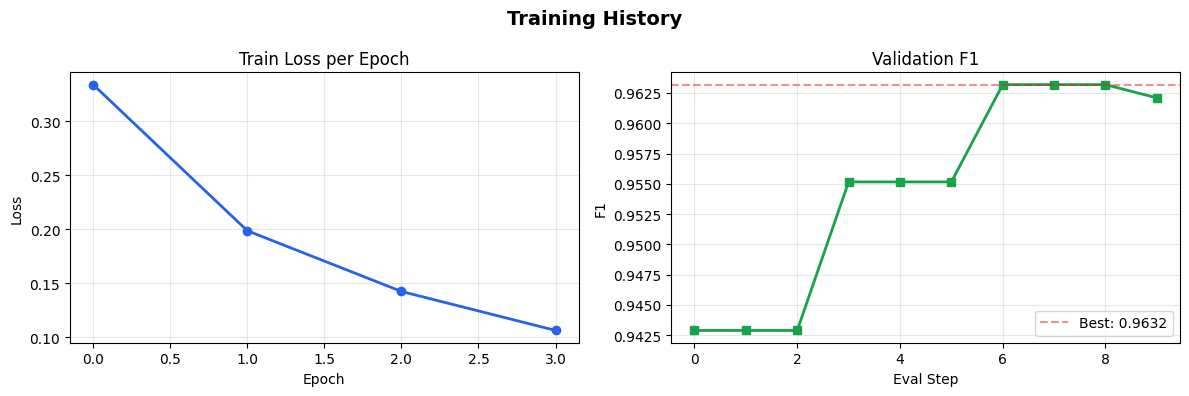

Saved → /content/outputs/training_curves.png


In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

ax1.plot(train_loss_history, color="#2563EB", marker="o", linewidth=2)
ax1.set_title("Train Loss per Epoch"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(alpha=0.3)

ax2.plot(val_f1_history, color="#16A34A", marker="s", linewidth=2)
ax2.set_title("Validation F1"); ax2.set_xlabel("Eval Step"); ax2.set_ylabel("F1")
ax2.grid(alpha=0.3)
ax2.axhline(y=max(val_f1_history) if val_f1_history else 0,
            color="#DC2626", linestyle="--", alpha=0.5, label=f"Best: {max(val_f1_history):.4f}")
ax2.legend()

plt.tight_layout()
plt.savefig("/content/outputs/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/outputs/training_curves.png")


## 8️⃣ Evaluation — Confusion Matrix + ROC Curve

              precision    recall  f1-score   support

    Negative     0.9089    0.8522    0.8796       866
    Positive     0.9492    0.9700    0.9595      2464

    accuracy                         0.9393      3330
   macro avg     0.9290    0.9111    0.9195      3330
weighted avg     0.9387    0.9393    0.9387      3330



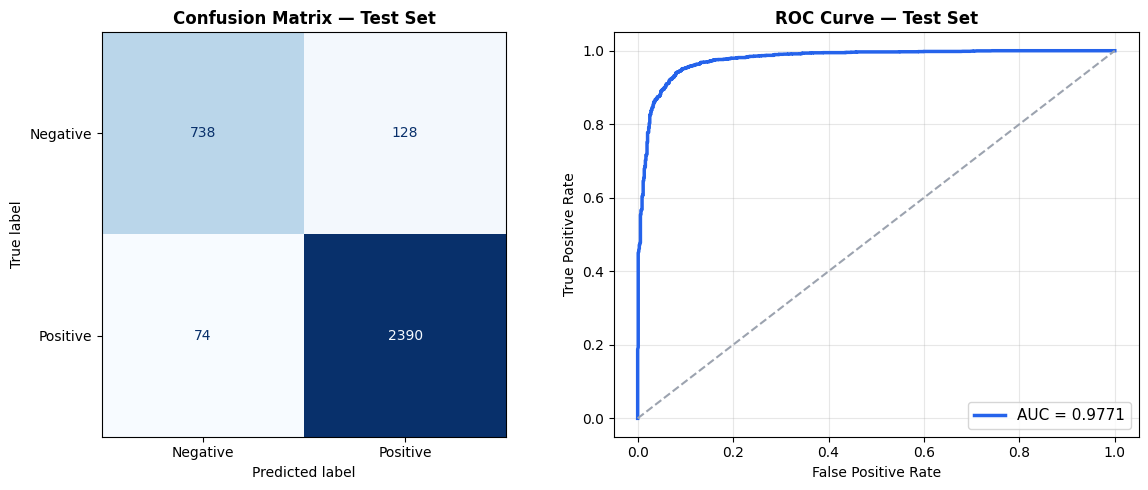

In [20]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
import torch.nn.functional as F
from torch.amp import autocast

@torch.no_grad()
def get_all_predictions(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        aux  = batch["aux_features"].to(DEVICE)
        lbl  = batch["labels"].to(DEVICE)
        with autocast(device_type='cuda', enabled=CFG.fp16):
            out = model(ids, mask, aux)
        all_logits.append(out["logits"].cpu().float().numpy())
        all_labels.append(lbl.cpu().numpy())
    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels)
    probs  = torch.softmax(torch.tensor(logits), -1).numpy()
    return logits, probs, labels

logits, probs, labels = get_all_predictions(model, test_loader)
preds = logits.argmax(-1)

# ── Classification Report ──────────────────────────────────────────────────
report = classification_report(labels, preds,
                                target_names=["Negative","Positive"], digits=4)
print(report)

# ── Plots ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm   = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative","Positive"])
disp.plot(ax=ax1, colorbar=False, cmap="Blues")
ax1.set_title("Confusion Matrix — Test Set", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(labels, probs[:,1])
roc_auc     = auc(fpr, tpr)
ax2.plot(fpr, tpr, color="#2563EB", lw=2.5, label=f"AUC = {roc_auc:.4f}")
ax2.plot([0,1],[0,1], color="#9CA3AF", linestyle="--", lw=1.5)
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve — Test Set", fontweight="bold")
ax2.legend(loc="lower right", fontsize=11); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/outputs/evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔍 SHAP — Feature Importance on Auxiliary Features

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


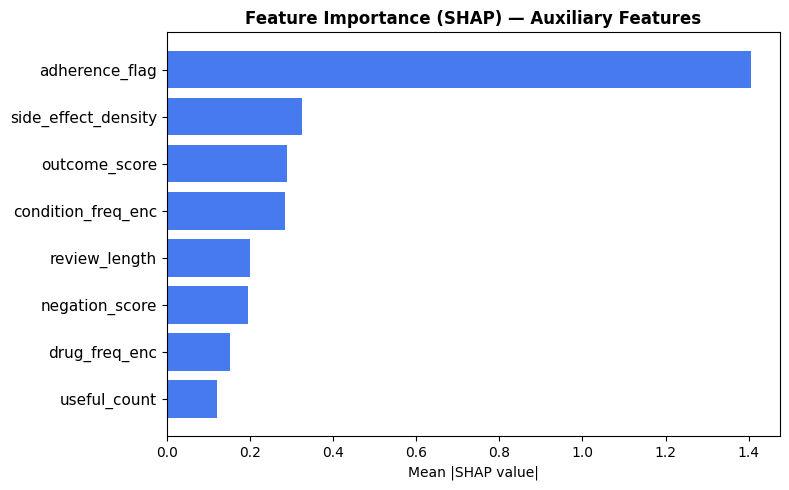

✅ SHAP analysis complete


In [21]:
try:
    import shap
    from lightgbm import LGBMClassifier

    X = test_df[AUX_COLS].fillna(0).values
    y = preds

    surrogate = LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                num_leaves=31, random_state=42, verbose=-1)
    surrogate.fit(X, y)

    explainer   = shap.TreeExplainer(surrogate)
    shap_values = explainer.shap_values(X)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.abs(sv).mean(0)
    idx      = np.argsort(mean_abs)[::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(range(len(AUX_COLS))[::-1], mean_abs[idx], color="#2563EB", alpha=0.85)
    ax.set_yticks(range(len(AUX_COLS)))
    ax.set_yticklabels([AUX_COLS[i] for i in idx], fontsize=11)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title("Feature Importance (SHAP) — Auxiliary Features", fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/outputs/shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ SHAP analysis complete")
except ImportError:
    print("lightgbm/shap not available — run: !pip install shap lightgbm")


## 9️⃣ Inference — Predict on New Reviews

In [24]:
@torch.no_grad()
def predict(review_text: str, drug_name: str = "", condition: str = "") -> dict:
    """Predict sentiment for a single patient review."""
    model.eval()
    text = re.sub(r"\s+", " ", review_text.strip())
    enc  = tokenizer(text, max_length=CFG.max_length, padding="max_length",
                     truncation=True, return_tensors="pt")
    ids  = enc["input_ids"].to(DEVICE)
    mask = enc["attention_mask"].to(DEVICE)

    # Build aux features from text
    aux_vals = [
        side_effect_density(text),
        negation_score(text),
        float(adherence_flag(text)),
        outcome_score(text),
        float(len(text.split())),
        0.0, 0.01, 0.01,   # useful_count, drug_freq, cond_freq (unknown at serve time)
    ]
    aux = torch.tensor([aux_vals], dtype=torch.float32).to(DEVICE)

    with autocast(device_type='cuda', enabled=CFG.fp16):
        out = model(ids, mask, aux)

    probs = F.softmax(out["logits"], -1).squeeze(0).cpu().tolist()
    pred  = int(out["logits"].argmax(-1).item())
    label = "🟢 POSITIVE" if pred == 1 else "🔴 NEGATIVE"

    print(f"Review   : {text[:100]}{'...' if len(text)>100 else ''}")
    print(f"Prediction: {label}  (confidence: {max(probs):.1%})")
    print(f"Probs     : negative={probs[0]:.4f}  positive={probs[1]:.4f}")
    print()
    return {"label": "positive" if pred==1 else "negative",
            "confidence": round(max(probs),4), "probs": probs}

# ── Demo predictions ───────────────────────────────────────────────────────
print("=" * 60)
print("INFERENCE DEMO")
print("=" * 60 + "\n")

test_reviews = [
    ("This medication changed my life. After 3 years I am finally stable and "
     "functioning. Still taking it and would never switch.",
     "Sertraline", "depression"),

    ("Terrible side effects — nausea, dizziness, weight gain every single day. "
     "Stopped after two months. Didn't help at all with my anxiety.",
     "Quetiapine", "anxiety"),

    ("Worked okay at first but then stopped helping. Switched to something else. "
     "The brain fog and memory problems were unbearable.",
     "Venlafaxine", "generalized anxiety disorder"),

    ("Finally sleeping through the night. Mood is so much better. "
     "Recovery feels real for the first time in years.",
     "Lamotrigine", "bipolar disorder"),
]

results = []
for review, drug, cond in test_reviews:
    r = predict(review, drug, cond)
    results.append(r)


INFERENCE DEMO

Review   : This medication changed my life. After 3 years I am finally stable and functioning. Still taking it ...
Prediction: 🟢 POSITIVE  (confidence: 99.6%)
Probs     : negative=0.0038  positive=0.9961

Review   : Terrible side effects — nausea, dizziness, weight gain every single day. Stopped after two months. D...
Prediction: 🔴 NEGATIVE  (confidence: 99.5%)
Probs     : negative=0.9946  positive=0.0056

Review   : Worked okay at first but then stopped helping. Switched to something else. The brain fog and memory ...
Prediction: 🔴 NEGATIVE  (confidence: 99.1%)
Probs     : negative=0.9912  positive=0.0089

Review   : Finally sleeping through the night. Mood is so much better. Recovery feels real for the first time i...
Prediction: 🟢 POSITIVE  (confidence: 99.7%)
Probs     : negative=0.0033  positive=0.9966



## 💾 Save All Outputs to Google Drive (Optional)

In [25]:
# Optional: mount Google Drive and save model + outputs
SAVE_TO_DRIVE = False  # ← Set True to save

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    import shutil
    dest = "/content/drive/MyDrive/psych_sentiment_pipeline"
    shutil.copytree("/content/outputs", f"{dest}/outputs", dirs_exist_ok=True)
    shutil.copy(CFG.ckpt_path, f"{dest}/best_model.pt")
    print(f"✅ Saved to Google Drive: {dest}")
else:
    # Download outputs zip locally
    import shutil
    shutil.make_archive("/content/pipeline_outputs", "zip", "/content/outputs")
    from google.colab import files
    files.download("/content/pipeline_outputs.zip")
    print("✅ Downloaded pipeline_outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded pipeline_outputs.zip


## 📊 View MLflow Experiment Logs

In [26]:
# Launch MLflow UI via ngrok tunnel
# Requires: pip install pyngrok

try:
    from pyngrok import ngrok
    !mlflow ui --backend-store-uri /content/mlruns --port 5000 &
    import time; time.sleep(3)
    tunnel = ngrok.connect(5000)
    print(f"✅ MLflow UI: {tunnel.public_url}")
except ImportError:
    print("Install pyngrok to view MLflow UI: !pip install pyngrok")
    print("Or view logged metrics above in the training output.")

    # Print summary from MLflow
    import mlflow
    mlflow.set_tracking_uri("/content/mlruns")
    runs = mlflow.search_runs(experiment_names=["psych-sentiment"])
    if not runs.empty:
        cols = [c for c in runs.columns if "metric" in c or "param" in c]
        print("\nLogged metrics & params:")
        print(runs[cols].to_string())


Install pyngrok to view MLflow UI: !pip install pyngrok
Or view logged metrics above in the training output.

Logged metrics & params:
   metrics.train_loss params.lr params.freeze_layers params.epochs                                                   params.model params.use_aux
0             0.02923     2e-05                    6             4  microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext           True


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
